In [1]:
import pandas as pd
import os
from nltk.tokenize import word_tokenize
import numpy as np
import csv
import matplotlib.pyplot as plt
import re

In [2]:
OUTPUT_DIR = './processedData/'

In [3]:
prompt_df = pd.read_csv('../promptDataPreparation/promptDataPreparation.csv')

In [4]:
sentence_lengths = {}
for dataset in os.listdir(f'./data'):
    if os.path.isdir(f'./data/{dataset}'):
        sentence_lengths[dataset] = {}
        for file in os.listdir(f'./data/{dataset}'):
            if file.endswith('.csv'):
                temp_file_name = file.split('-')[1].replace('.csv', '')
                sentence_lengths[dataset][temp_file_name] = []
                for note in pd.read_csv(f'./data/{dataset}/{file}')['report'].to_list():
                    sentence_lengths[dataset][temp_file_name].append(len(word_tokenize(note)))

clinc150 LDA


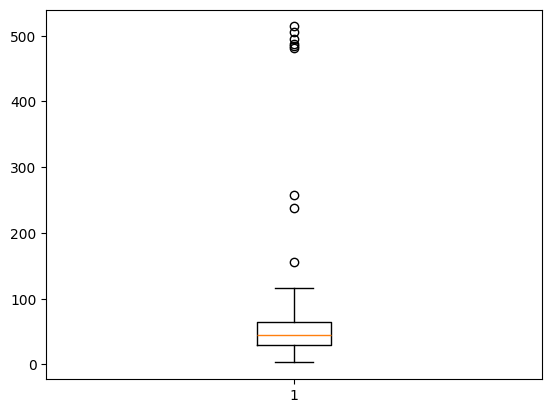

clinc150 MATAVE


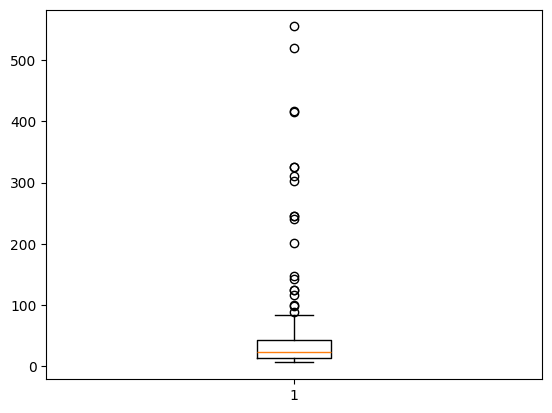

medicalAbstracts LDA


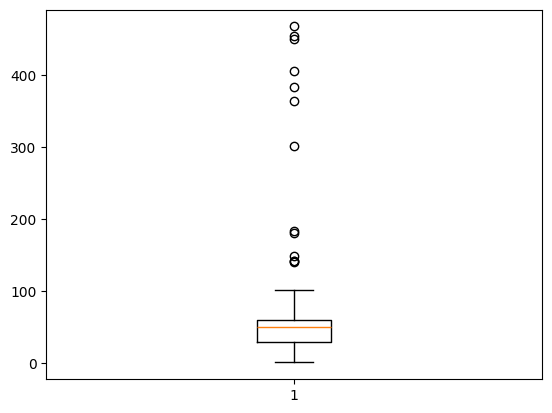

medicalAbstracts MATAVE


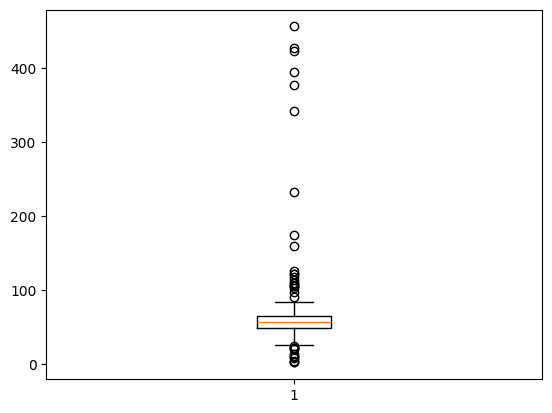

huffPostNews LDA


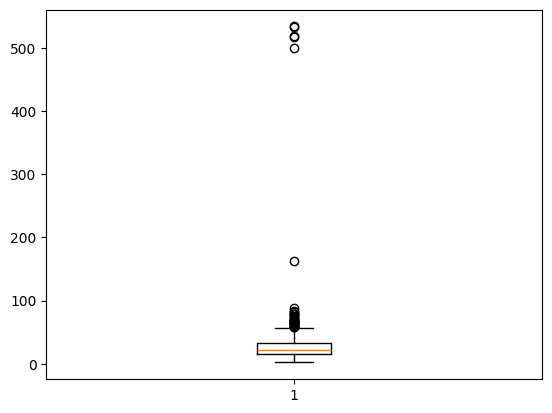

huffPostNews MATAVE


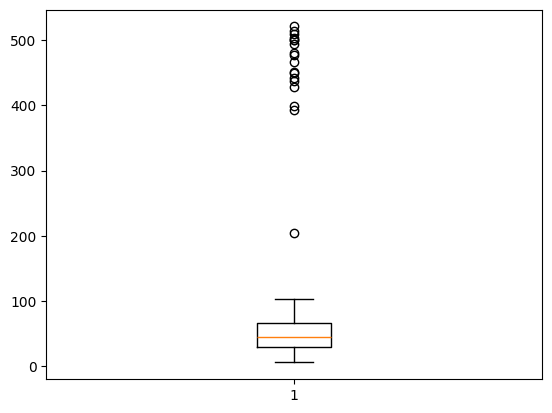

atis LDA


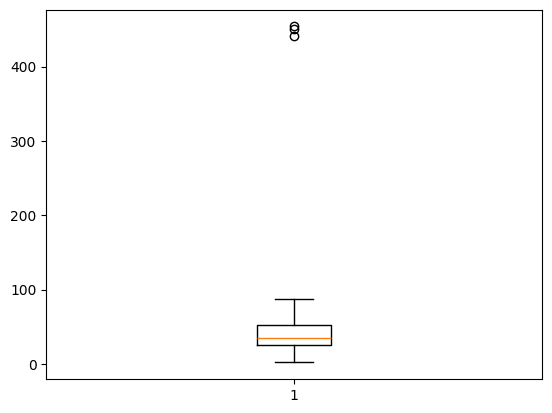

atis MATAVE


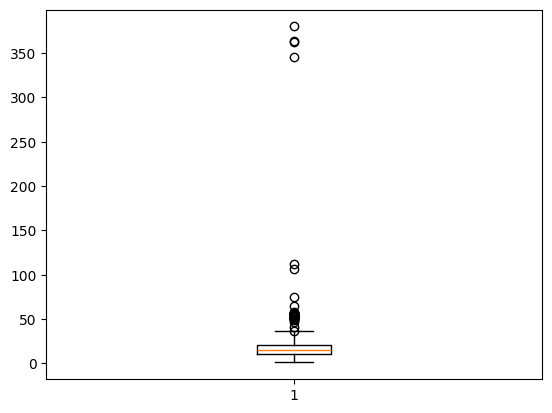

dementiaAudio MATAVE


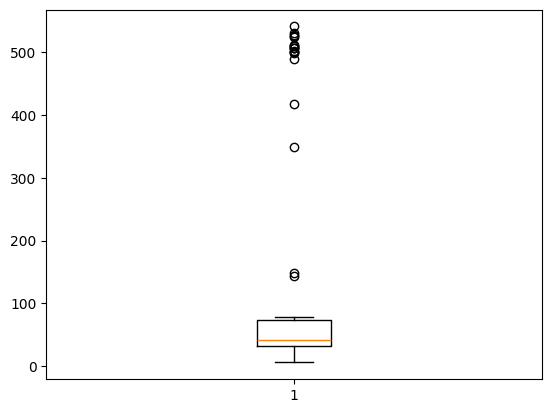

dementiaAudio LDA


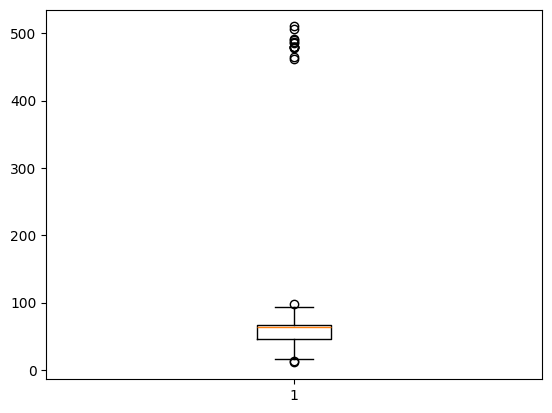

banking77 LDA


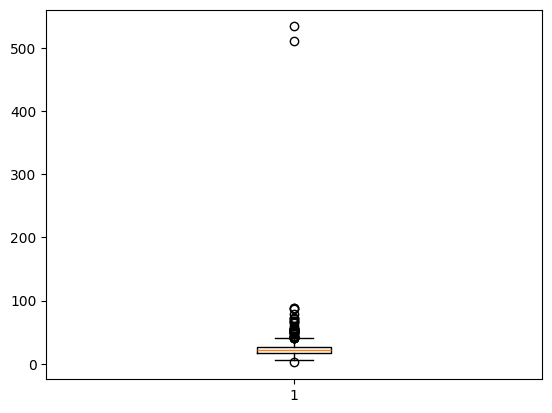

banking77 MATAVE


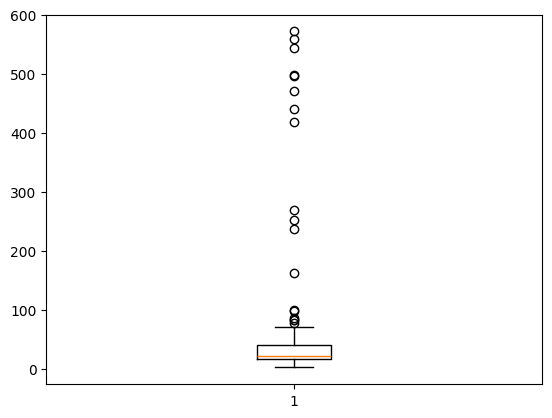

clinicalDialogueSummarizations MATAVE


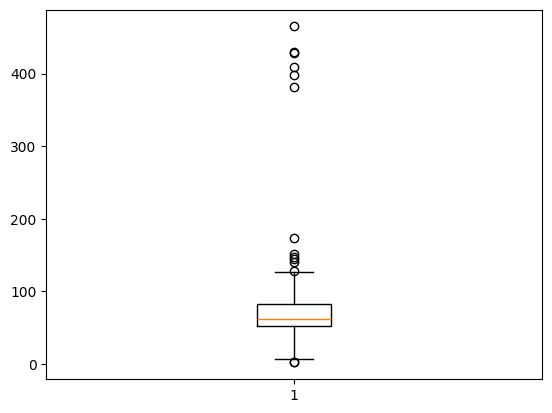

clinicalDialogueSummarizations LDA


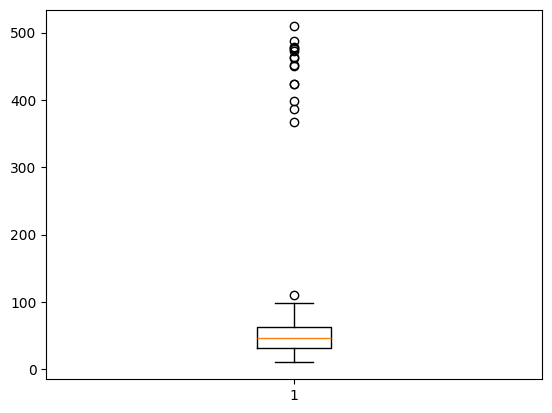

syntheticCareHomeNurseNotes MATAVE


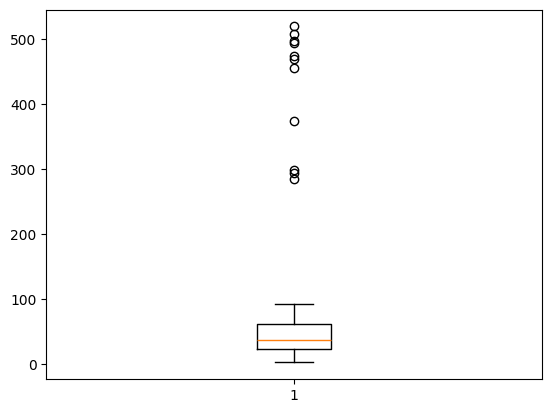

syntheticCareHomeNurseNotes LDA


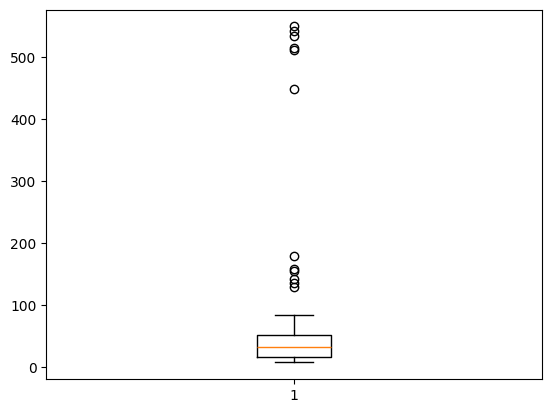

simSUM LDA


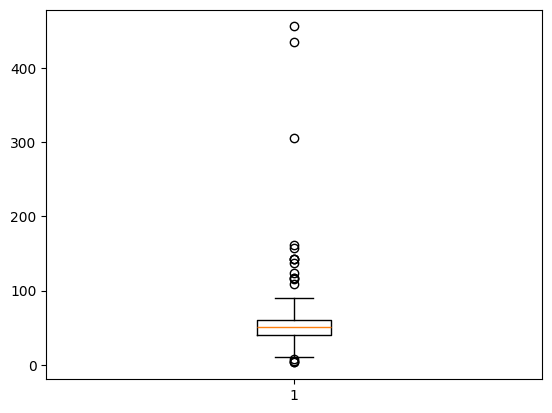

simSUM MATAVE


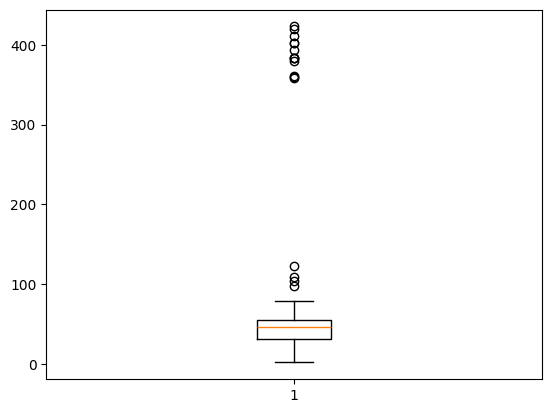

yahoo MATAVE


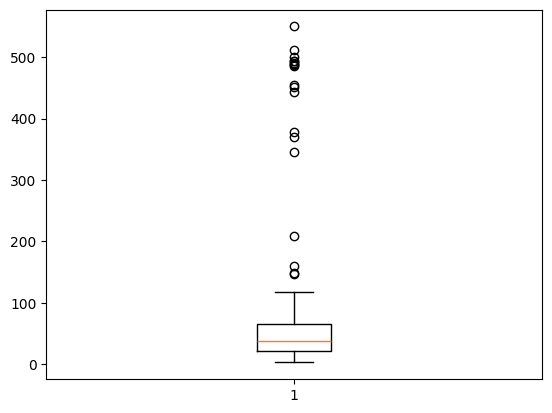

yahoo LDA


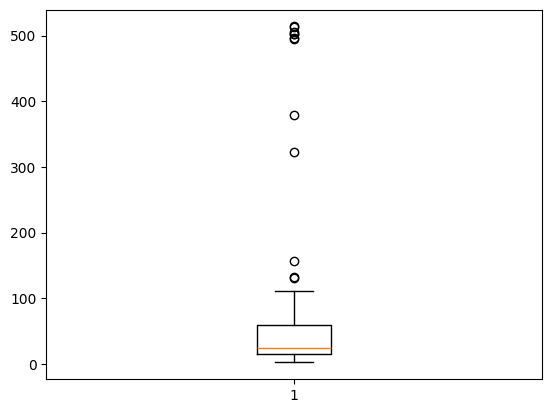

In [5]:
for dataset, values in sentence_lengths.items():
    for model_name, model_values in values.items():
        print(dataset, model_name)
        plt.boxplot(model_values);
        plt.show()

In [6]:
upper_and_lower_bounds = {}

for dataset, values in sentence_lengths.items():
    upper_and_lower_bounds[dataset] = {}
    
    for topic_model, lengths in values.items():
        l = np.array(lengths)
        
        q1 = np.quantile(l, 0.25)
        q3 = np.quantile(l, 0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        # store bounds
        upper_and_lower_bounds[dataset][topic_model] = {
            'lower': lower,
            'upper': upper
        }

In [7]:
def clean_note(text):
    text = re.sub(r'^[\s"]+|[\s"]+$', '', text)   # strip edge quotes/spaces
    text = re.sub(r'\*', '', text)                 # remove asterisks
    text = re.sub(r'\s+', ' ', text)              # normalize whitespace
    return text.strip()

In [8]:
# Remove texts of x length above and below the 10% and 90% percentiles in the list.
for dataset in os.listdir(f'./data'):
    if os.path.isdir(f'./data/{dataset}'):
        notes_for_output = []
        relevant_prompt = []
        topic_model_prompt_ids = []
        topic_models = []
        prompt_ids = []
        datasets = []
        raw_notes = []
        for file in os.listdir(f'./data/{dataset}'):
            if file.endswith('.csv'):
                example_note_index = int(file.split('-')[0])
                temp_topic_model = file.split('-')[1].replace('.csv', '')
                prompt = (prompt_df[(prompt_df['dataset'] == dataset) & (prompt_df['topic_model'] == temp_topic_model)]['example_notes'].to_list()[0].split('*** SEPARATION ***'))[example_note_index]
                notes = pd.read_csv(f'./data/{dataset}/{file}')['report'].to_list()
                raw_notes.extend(notes)
                for note in notes:
                    # raw_segments = re.split(r'\s*"+(?:\s*"+)+\s*', note)
                    raw_segments = re.split(r'\s*(?:"{2,}\s*){1,}"+\s*', note)
                    for segment in raw_segments:
                        segment = clean_note(segment)

                        if not segment:
                            continue

                        temp_length = len(word_tokenize(segment))
                    # Filter based on lower bound vs 6 words max and upper bound. 
                    if max(upper_and_lower_bounds[dataset][temp_topic_model]['lower'], 5) <= temp_length <= upper_and_lower_bounds[dataset][temp_topic_model]['upper']:
                        # remove any note with accidental reference to the topic model keywords
                        if 'other topic keywords:' not in segment.lower():
                            # Remove accidental reference to the input prompt.
                            if prompt.lower() not in segment.lower():
                                topic_model_prompt_ids.append(file.replace('.csv', ''))
                                datasets.append(dataset)
                                relevant_prompt.append(prompt)
                                
                                notes_for_output.append(segment)
                                prompt_ids.append(example_note_index)
                                topic_models.append(temp_topic_model)
                            else:
                                # print(f'{dataset} DIRECT PROMPT REFERENCE {prompt} - {note}')
                                pass
                        else:
                            # print(f'{dataset} DIRECT KEYWORDS REFERENCE {prompt} - {note}')
                            pass
                    else:
                        # print(f"{dataset} TOO LONG {note} is {temp_length} tokens long, which falls outside the range of {upper_and_lower_bounds[dataset][temp_topic_model]['lower']} - {upper_and_lower_bounds[dataset][temp_topic_model]['upper']}")
                        pass
        os.makedirs(f'./{OUTPUT_DIR}/', exist_ok=True)
        output_df = pd.DataFrame({
            'topic_model_prompt_ids' : topic_model_prompt_ids,
            'topic_model' : topic_models,
            'prompt_id' : prompt_ids,
            'datasets' : datasets,
            'example_text_in_prompt' : relevant_prompt,
            'report' : notes_for_output,
        })
        output_df = output_df[output_df['report'].notna() & (output_df['report'] != "")]
        output_df = output_df.drop_duplicates(subset=['report'])
        output_df.to_csv(f'./{OUTPUT_DIR}/{dataset}.csv', index=False, quoting=csv.QUOTE_ALL, encoding='utf-8', lineterminator='\n')
        print(f"{dataset}: {len(raw_notes)} vs {len(output_df)}")

clinc150: 4654 vs 3997
medicalAbstracts: 3511 vs 3071
huffPostNews: 5868 vs 5012
atis: 3076 vs 2034
dementiaAudio: 3376 vs 2560
banking77: 2342 vs 1794
clinicalDialogueSummarizations: 4491 vs 3720
syntheticCareHomeNurseNotes: 2554 vs 2267
simSUM: 1659 vs 1392
yahoo: 3379 vs 2664
